# `hg_porosimetry`
Simulates a mercury intrusion-extrusion experiment by running a `drainage` and an `imbibition` from all faces using mercury contact angle and surface tension. Returns the two pressure-saturation curves.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.simulations.hg_porosimetry)

<Signature (im, steps=25, voxel_size=1.0)>

## `im`
A boolean image with `True` indicating the void phase. Both 2D and 3D images are supported, but 3D is the typical use case.

In [3]:
im = ps.generators.blobs(
    shape=[60, 60, 60], porosity=0.6, blobiness=1.5, seed=0)
mip = ps.simulations.hg_porosimetry(im=im, voxel_size=1e-5)

## Plotting the result
The returned object holds four arrays: `pc_intrusion` and `snwp_intrusion` for the drainage curve, plus `pc_extrusion` and `snwp_extrusion` for the imbibition curve. Plotting `log10(Pc)` vs. mercury saturation gives a familiar MIP hysteresis loop.

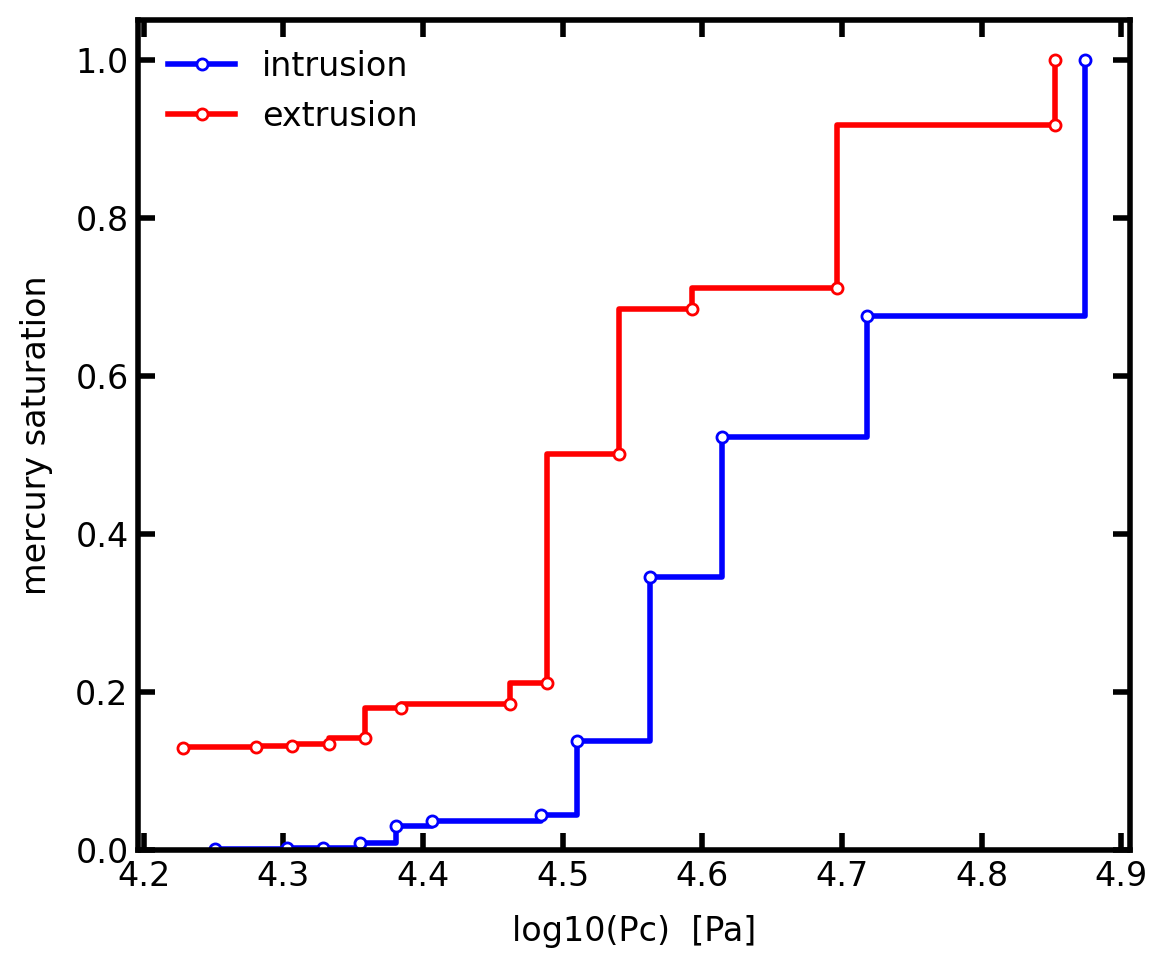

In [4]:
fig, ax = plt.subplots(figsize=[6, 5])
ax.step(np.log10(mip.pc_intrusion), mip.snwp_intrusion, 'b.-',
        where='post', label='intrusion')
ax.step(np.log10(mip.pc_extrusion), mip.snwp_extrusion, 'r.-',
        where='post', label='extrusion')
ax.set_xlabel('log10(Pc)  [Pa]')
ax.set_ylabel('mercury saturation')
ax.set_ylim([0, 1.05])
ax.legend();

## `voxel_size`
Image resolution in metres per voxel. Mercury surface tension and contact angle are hard-coded (sigma = 0.465 N/m, theta = 140 deg), so `voxel_size` is the knob that sets the absolute pressure scale on the x-axis.

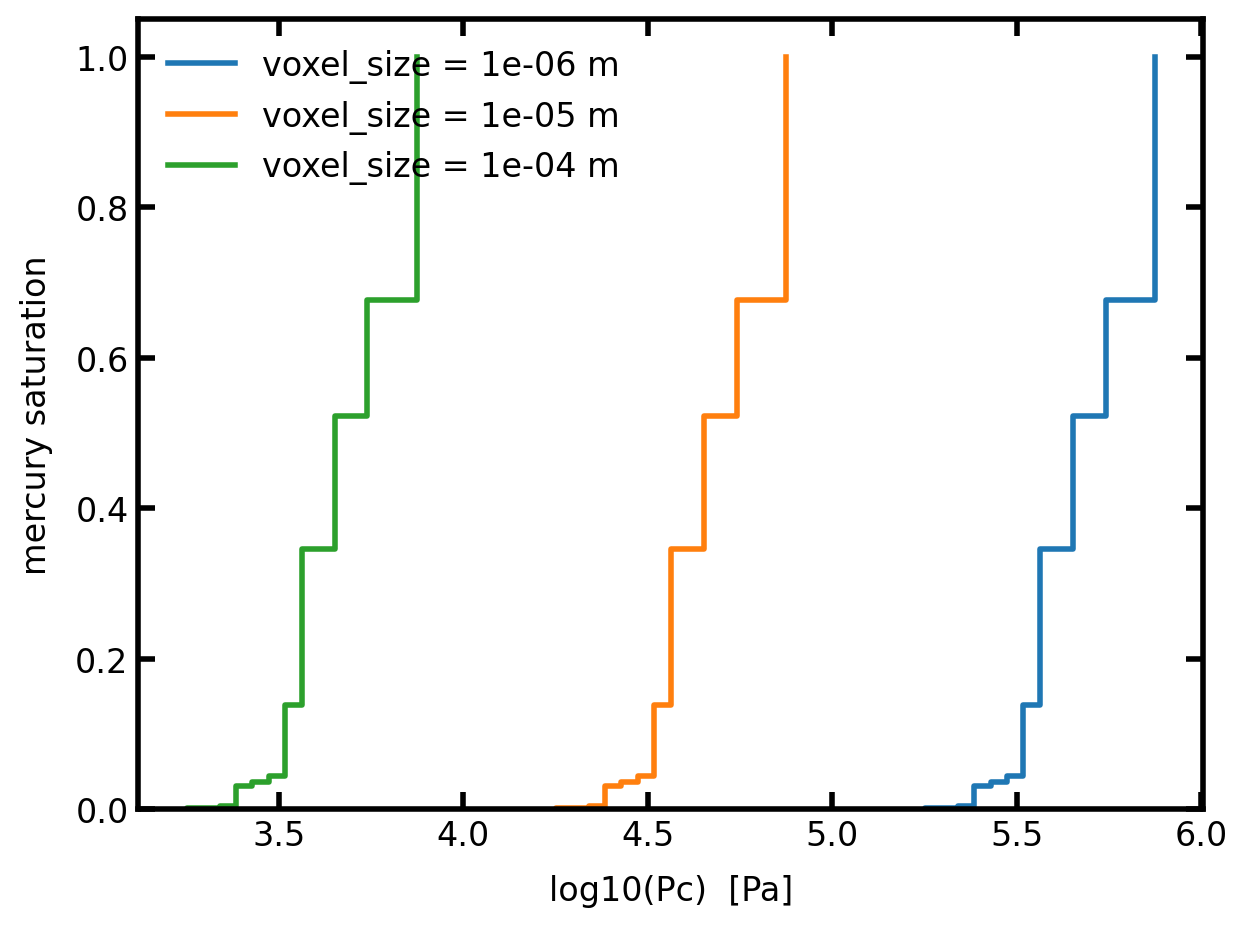

In [5]:
for vs in [1e-6, 1e-5, 1e-4]:
    mip = ps.simulations.hg_porosimetry(im=im, voxel_size=vs, steps=15)
    plt.step(np.log10(mip.pc_intrusion), mip.snwp_intrusion,
             where='post', label=f'voxel_size = {vs:.0e} m')
plt.xlabel('log10(Pc)  [Pa]')
plt.ylabel('mercury saturation')
plt.ylim([0, 1.05])
plt.legend();

## `steps`
Number of pressure steps used for both intrusion and extrusion. More steps give a smoother curve at higher cost. The default is 25.

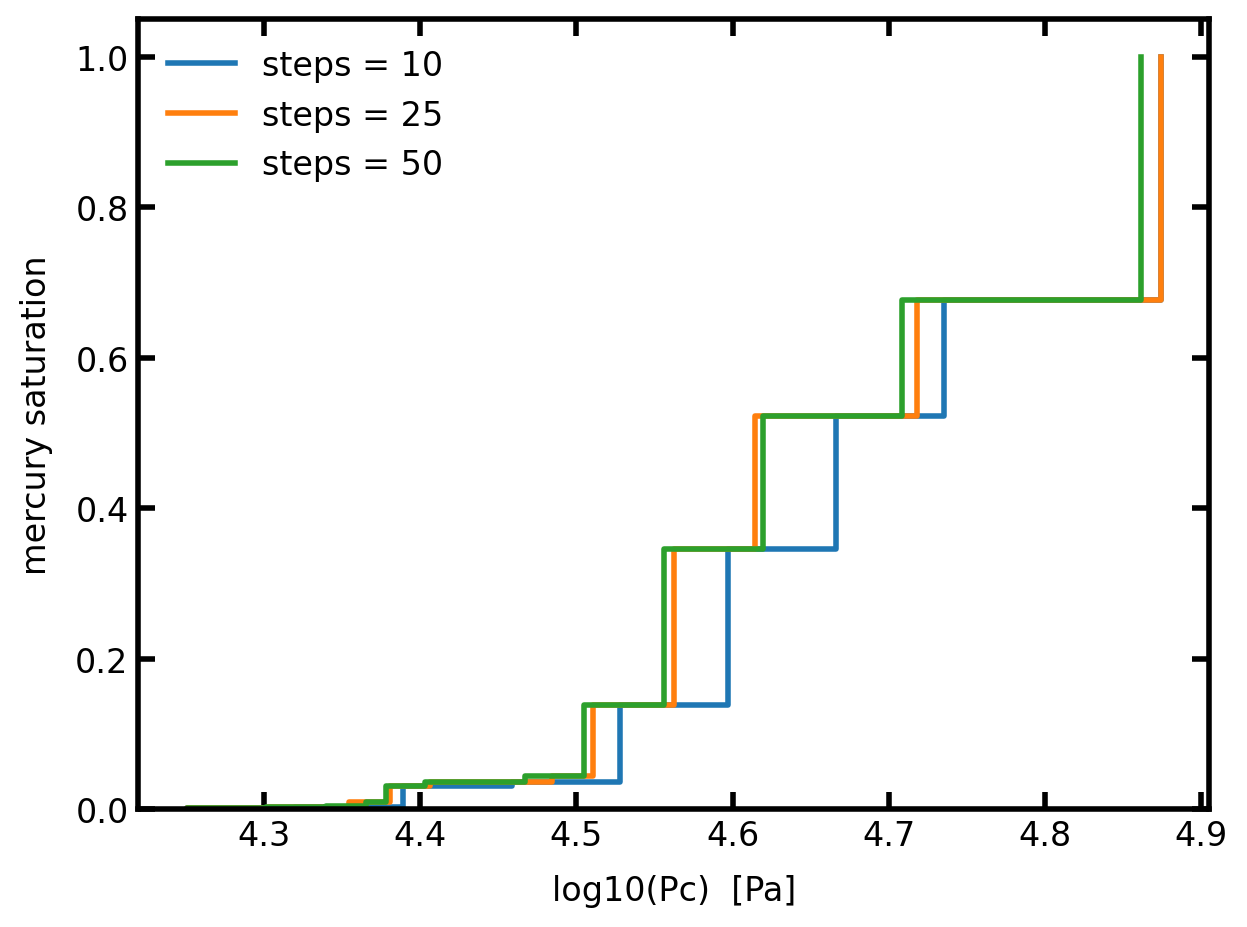

In [6]:
for n in [10, 25, 50]:
    mip = ps.simulations.hg_porosimetry(im=im, voxel_size=1e-5, steps=n)
    plt.step(np.log10(mip.pc_intrusion), mip.snwp_intrusion,
             where='post', label=f'steps = {n}')
plt.xlabel('log10(Pc)  [Pa]')
plt.ylabel('mercury saturation')
plt.ylim([0, 1.05])
plt.legend();